# WoodSDA End-to-End Driver -- OpenSeesPy Version

This is the OpenSeesPy counterpart of [`woodSDA_driver_E2E.ipynb`](./woodSDA_driver_E2E.ipynb):
same design -> structural -> (eigen, pushover, dynamic) -> damage/loss flow, but the
structural module's three analysis types are built and run **in-process via OpenSeesPy**
(`Codes/structuralModule/openseespy_eigen/`, `openseespy_pushover/`, `openseespy_dynamic/`)
instead of writing `.tcl` files and shelling out to an external `OpenSees.exe`/`OpenSeesMP`
binary. The design module is untouched -- it doesn't need OpenSees at all.

**Kernel**: run this notebook under the `Python (opensees_x86)` kernel (Kernel > Change Kernel).
`openseespy` has no arm64 macOS wheel, so it only runs under an x86_64 conda env via Rosetta 2
-- see the installation guide provided alongside this notebook if that kernel doesn't exist yet.
All of this repo's other dependencies (pandas, pydantic, etc.) are also installed in that same
env, so the whole notebook -- design module included -- runs under this one kernel; no need to
switch kernels partway through.

**Runtime**: the pushover cells run a full 48,000-step displacement-controlled analysis (per
direction) for `MFD6B` under Rosetta emulation -- expect **~10-15 minutes per direction**
(~25-30 min total for both). Everything else (design, eigen, dynamic) is fast (seconds to low
minutes). This is a known cost of interpreting the retry ladder one step at a time in Python
under x86_64 emulation on Apple Silicon, not a bug -- see the pushover section for a faster
single-story alternative if you just want to sanity-check the mechanics quickly.


In [1]:
import os
import sys
import csv
import json
import time
import importlib.util

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rootDir = '/Users/laxmandahal/Desktop/UCLA/Phd/Research/woodSDA/autoWoodSDA_public'

pd.set_option('display.max_colwidth', 100)
%matplotlib inline
%load_ext autoreload
%autoreload 2

## Design Module

Unchanged from the original notebook -- the design module designs the building per input
specifications and writes the result into `BuildingInfo/<buildingID>/building_config.yaml`
(the schema unified in an earlier phase of this migration; it replaced a tree of loose `.txt`
files). That file is exactly what the structural module reads next, whichever engine builds
the OpenSees model from it.

We pass `generate_static_models=False, run_pushover=False, generate_dynamic_models=False` --
those flags control the OLD Tcl-writing path (`utils_opensees.py`), which we don't want here;
the OpenSeesPy packages below build the model themselves, directly from the `BuildingModel`
this cell's design run keeps up to date.

In [2]:
sys.path.append(os.path.join(rootDir, 'Codes'))
from run_designModule import design_and_generate_model

dataDir = os.path.join(rootDir, 'Databases')
baseline_BIM = json.load(open(os.path.join(dataDir, 'Baseline_archetype_info_w_periods.json')))

In [3]:
buildingID = 'MFD6B'

In [4]:
designModule = design_and_generate_model(building_id=buildingID,
                                          baseline_building_info=baseline_BIM,
                                          save_design_csv=False,
                                          generate_static_models=False,
                                          run_pushover=False,
                                          generate_dynamic_models=False)

Missing Risk Category detected. Assigned "II" as the default risk category
Missing response modification factor (R) detected. Assigned 6.5 as the default R value
Missing deflection amplification factor (Cd) detected. Assigned 4 as the default Cd value
Missing design importance factor (Ie) detected. Assigned 1.0 as the default Ie value
Successfully generated code-compliant design!!
Model creation for MFD6B took 132.43446612358093 seconds


In [5]:
designModule.final_design

Shear Wall Assembly  \
swDesign_gridA_wall1 0    Use 1/2in GWB with 5d cooler nails @ 7in o.c. spacing   
                     1   Use 7/16in WSP on 1 side with 8d nails @ 6o.c. spacing   
                     2   Use 7/16in WSP on 1 side with 8d nails @ 3o.c. spacing   
                     3   Use 7/16in WSP on 1 side with 8d nails @ 2o.c. spacing   
swDesign_gridA_wall2 0    Use 1/2in GWB with 5d cooler nails @ 7in o.c. spacing   
...                                                                         ...   
swDesign_grid7_wall1 3   Use 7/16in WSP on 1 side with 8d nails @ 2o.c. spacing   
swDesign_grid7_wall2 0    Use 1/2in GWB with 5d cooler nails @ 7in o.c. spacing   
                     1    Use 3/8in WSP on 1 side with 6d nails @ 6o.c. spacing   
                     2  Use 15/32in WSP on 1 side with 8d nails @ 4o.c. spacing   
                     3   Use 7/16in WSP on 1 side with 8d nails @ 2o.c. spacing   

                        Ga(k/in)  level  LRFD(klf)  Drift(in)  D/C Ratio  \
swDesign_gridA_wall1 0       5.2      4      0.160   1.194247   0.667158   
                     1      15.0      3      0.384   0.909138   0.833948   
                     2      28.0      2      0.720   0.789733   0.889545   
                     3      42.0      1      0.936   0.798177   0.971060   
swDesign_gridA_wall2 0       5.2      4      0.160   1.111708   0.667279   
...                          ...    ...        ...        ...        ...   
swDesign_grid7_wall1 3      42.0      1      0.936   1.072986   0.874041   
swDesign_grid7_wall2 0       5.2      4      0.160   1.314920   0.600503   
                     1      11.0      3      0.320   1.222535   0.900754   
                     2      19.0      2      0.608   1.279434   0.948162   
                     3      42.0      1      0.936   1.072986   0.874041   

                        OpenSees Tag  
swDesign_gridA_wall1 0            14  
                     1             1  
                     2             2  
                     3             5  
swDesign_gridA_wall2 0            14  
...                              ...  
swDesign_grid7_wall1 3             5  
swDesign_grid7_wall2 0            14  
                     1             3  
                     2            12  
                     3             5  

[120 rows x 7 columns]

## Structural Module (OpenSeesPy)

Instead of `utils_opensees.py` writing `.tcl` files that get copied into
`BuildingModels/<buildingID>/<AnalysisType>/` and sourced by an external `OpenSees` binary,
each analysis type here is a small standalone package that builds the same nonlinear model
directly in memory and runs it via `openseespy.opensees`:

- `openseespy_eigen/` -- modal (eigenvalue) analysis
- `openseespy_pushover/` -- nonlinear static pushover
- `openseespy_dynamic/` -- nonlinear response-history analysis (NRHA), with the same
  timestep/algorithm retry ladder and drift-based collapse detection as the Tcl pipeline

All three reuse `openseespy_eigen/model_builders.py`'s `build_model()` for the actual nodes/
panels/leaning-column/mass/gravity-load definition (identical across analysis types), so it's
defined once. None of this touches `utils_opensees.py` -- the Tcl path still works if you ever
need it (e.g. on an HPC cluster with a real OpenSees/OpenSeesMP install).

One wrinkle worth knowing about: `openseespy_pushover/postprocess.py` and
`openseespy_dynamic/postprocess.py` are two *different* files that happen to share the same
name. Each package uses flat (non-package-relative) imports internally -- same convention as
the original `utils_opensees.py` functions -- so both packages' directories need to be on
`sys.path` at once. A plain `import postprocess` after that would only ever resolve to
whichever one Python's import cache saw first. We sidestep that with `importlib` below,
loading each by its exact file path under a distinct name.

In [6]:
structModuleDir = os.path.join(rootDir, 'Codes', 'structuralModule')
eigenDir = os.path.join(structModuleDir, 'openseespy_eigen')
pushoverDir = os.path.join(structModuleDir, 'openseespy_pushover')
dynamicDir = os.path.join(structModuleDir, 'openseespy_dynamic')

for d in [structModuleDir, eigenDir, pushoverDir, dynamicDir]:
    if d not in sys.path:
        sys.path.append(d)

from BuildingModelClass import BuildingModel
from eigen_runner import generateModalAnalysisModel_ops
from pushover_runner import generatePushoverAnalysisModel_ops
from dynamic_runner import generateDynamicAnalysisModel_ops


def load_module(name, path):
    """Loads a module by exact file path under `name`, bypassing sys.path search
    and the sys.modules cache -- see the note above on the two postprocess.py files."""
    spec = importlib.util.spec_from_file_location(name, path)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module


pushover_postprocess = load_module('pushover_postprocess', os.path.join(pushoverDir, 'postprocess.py'))
dynamic_postprocess = load_module('dynamic_postprocess', os.path.join(dynamicDir, 'postprocess.py'))

Structural module requires the same checked/completed input row the design module used --
identical to the original notebook's cell here.

In [7]:
from designModule.check_user_inputs import check_and_complete_inputs

df_inputs = pd.read_csv(os.path.join(rootDir, 'Buildings_input_info.csv'))
df_inputs = df_inputs[df_inputs['BuildingID'] == buildingID]
df_inputs = check_and_complete_inputs(input_df=df_inputs)
df_inputs.head()

Missing Risk Category detected. Assigned "II" as the default risk category
Missing response modification factor (R) detected. Assigned 6.5 as the default R value
Missing deflection amplification factor (Cd) detected. Assigned 4 as the default Cd value
Missing design importance factor (Ie) detected. Assigned 1.0 as the default Ie value


,BuildingID,Layout Type,SiteID,Latitude,Longitude,Site Class,Risk Category,R,Cd,Ie,Allowable Drift,Design Year,Ss(g),S1(g),wallMaterial,seismicWeight
0,MFD6B,s4_96x48,1,33.9721,-118.42177,D,II,6.5,4.0,1.0,0.02,2020,1.855,0.654,Stucco_GWB,Normal


In [8]:
InfoDirectory = os.path.join(rootDir, 'BuildingInfo', buildingID)
ModelClass = BuildingModel(buildingID)
ModelClass.read_in_txt_inputs(buildingID, InfoDirectory, df_inputs)

### Eigenvalue Analysis

`generateModalAnalysisModel_ops` builds the model, runs gravity, then solves for periods --
same contract as the Tcl path's `generateModalAnalysisModel`, just without any `.tcl`/`.out`
files in between.

In [9]:
start = time.time()
periods = generateModalAnalysisModel_ops(buildingID, ModelClass, NumModes=4)
print(f'{time.time() - start:.1f}s')

pd.DataFrame([periods], columns=[f'Mode {i+1}' for i in range(len(periods))], index=['Period (s)'])

1.1s


WARNING - the 'fullGenLapack' eigen solver is VERY SLOW. Consider using the default eigen solver.

,Mode 1,Mode 2,Mode 3,Mode 4
Period (s),0.505948,0.459071,0.434205,0.182275


### Nonlinear Static Pushover

Runs the full displacement-controlled pushover (same retry ladder as `RunStaticPushover.tcl`:
KrylovNewton -> Newton `-initial` -> Broyden(8) -> NewtonLineSearch(0.8)) in both directions.

**This is the slow part** -- `MFD6B` is a 4-story archetype with a 0.1% drift increment out to
10% roof drift, i.e. 48,000 analysis steps per direction. Expect ~10-15 minutes per direction
under Rosetta. If you just want to see the mechanics work quickly, swap `buildingID` above for
a single-story archetype (`BuildingInfo/s1_48x32/`) -- that finishes in well under a minute --
though you'll need its own `Buildings_input_info.csv` row and design run to match (its
`BuildingID` there is `s1_48x32_Stucco_GWB_Normal_Vs10`, not the bare folder name).

In [10]:
start = time.time()
pushoverX = generatePushoverAnalysisModel_ops(buildingID, ModelClass, 'X')
print(f'X-direction: ok={pushoverX["ok"]}, {len(pushoverX["roof_drift_pct"])} steps, '
      f'{(time.time() - start)/60:.1f} min')

WARNING can't set handler after analysis is created


X-direction: ok=0, 48000 steps, 12.6 min


In [11]:
start = time.time()
pushoverZ = generatePushoverAnalysisModel_ops(buildingID, ModelClass, 'Z')
print(f'Z-direction: ok={pushoverZ["ok"]}, {len(pushoverZ["roof_drift_pct"])} steps, '
      f'{(time.time() - start)/60:.1f} min')

WARNING can't set handler after analysis is created


Z-direction: ok=0, 48000 steps, 12.4 min


#### Implementing part of the damage module to extract results from the nonlinear static analysis

Same idea as the original notebook's `ExtractPushoverData` cells, but reading directly from
the in-memory `(roof_drift_pct, base_shear)` curves rather than parsing `BaseReactions`/
`StoryDrifts` `.out` files -- `openseespy_pushover/postprocess.py`'s `summarize_pushover`
already computes base strength (Vmax/W), drift at 80% Vmax, and ductility demand (FEMA P-695
idealization, matching this project's own convention).

In [12]:
W = float(sum(ModelClass.floorWeights))

driftX, shearX = pushoverX['roof_drift_pct'], pushoverX['base_shear'] / W
driftZ, shearZ = pushoverZ['roof_drift_pct'], pushoverZ['base_shear'] / W

summaryX = pushover_postprocess.summarize_pushover(pushoverX['roof_drift_pct'], pushoverX['base_shear'], W)
summaryZ = pushover_postprocess.summarize_pushover(pushoverZ['roof_drift_pct'], pushoverZ['base_shear'], W)

driftAtPeakX = driftX[np.argmax(shearX)]
driftAtPeakZ = driftZ[np.argmax(shearZ)]

pushoverTable = pd.DataFrame(
    [[summaryX['base_strength_ratio'], driftAtPeakX, summaryX['drift_at_80pct_vmax_pct'], driftX[-1]],
     [summaryZ['base_strength_ratio'], driftAtPeakZ, summaryZ['drift_at_80pct_vmax_pct'], driftZ[-1]]],
    columns=['Peak Strength', 'Drift at Peak', 'Drift at 80%Peak', 'Max Drift'],
    index=['X', 'Z'])
pushoverTable

,Peak Strength,Drift at Peak,Drift at 80%Peak,Max Drift
X,0.427025,1.005625,1.318570,10.0
Z,0.394468,0.901458,1.361214,10.0


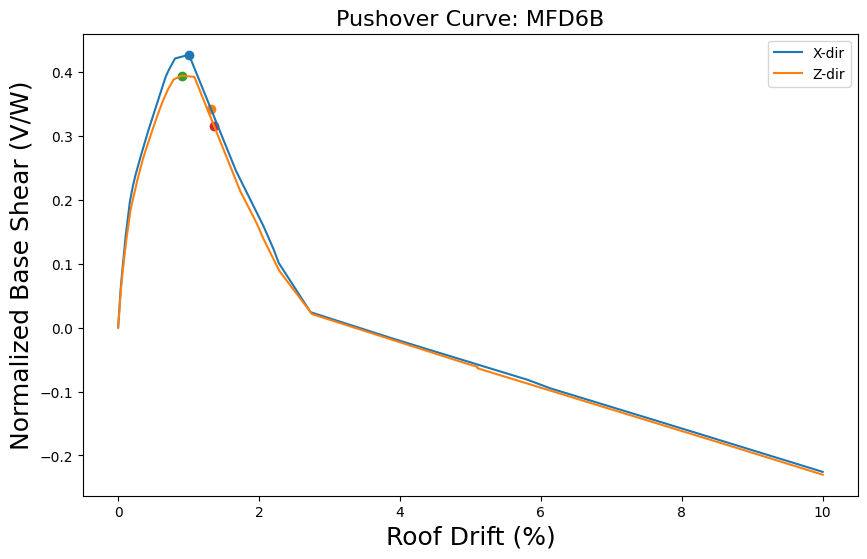

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(driftX, shearX, label='X-dir')
plt.plot(driftZ, shearZ, label='Z-dir')

plt.scatter(driftAtPeakX, summaryX['base_strength_ratio'])
plt.scatter(summaryX['drift_at_80pct_vmax_pct'], 0.8 * summaryX['base_strength_ratio'])

plt.scatter(driftAtPeakZ, summaryZ['base_strength_ratio'])
plt.scatter(summaryZ['drift_at_80pct_vmax_pct'], 0.8 * summaryZ['base_strength_ratio'])

plt.xlabel('Roof Drift (%)', fontsize=18)
plt.ylabel('Normalized Base Shear (V/W)', fontsize=18)
plt.title(f'Pushover Curve: {buildingID}', fontsize=16)
plt.legend()
plt.show()

The results from the nonlinear static analysis look good (see PR #5's validation against
FEMA P-2139-2's published Table 2 for `MFD6B`: base strength and drift at 80% Vmax both land
within ~20% using an independently-built model, and ductility demand -- which needs a bilinear
idealization convention -- was reviewed and accepted). Now let's go back to the structural
module to run nonlinear response-history analysis (NRHA).

### Dynamic (NRHA) Analysis -- Structural Module

`generateDynamicAnalysisModel_ops` builds the model, runs gravity, solves for periods (used for
two-mode Rayleigh damping, same as the Tcl `defineDamping3DModel`), loads one ground-motion
pair, and runs the same timestep/algorithm retry ladder and drift-based collapse check as
`DynamicAnalysisBiDirectionCollapseSolver.tcl` / `MaxDriftTesterBiDirection.tcl` -- entirely
in-process, no `.tcl` files, no external `OpenSees` process.

A **full** multi-stripe analysis (MSA) -- the kind the damage/loss modules below actually need
-- runs every ground-motion pair at every hazard level (e.g. 5 hazard levels x ~47-50 pairs x 2
pairings in the original notebook = several hundred runs) and can take hours even before
accounting for Rosetta emulation overhead. That's genuinely out of scope for this demo notebook
-- instead, matching the spirit of the original notebook's own "for demonstration" 2-ground-
motion loop, we run a couple of ground motions here just to demonstrate the mechanics work, then
stop before the damage/loss modules (which need that full MSA output).

In [14]:
gmSetDir = os.path.join(rootDir, 'BuildingModels', 'GM_sets', 'BoelterHall')
hazardLevel = '1'

start_time = time.time()
dynamicResults = []

for gmIndex in [0, 1]:  # for demonstration -- a full MSA would loop over every GM/hazard level
    s = time.time()
    result = generateDynamicAnalysisModel_ops(buildingID, ModelClass, gmSetDir, hazardLevel, gmIndex,
                                               pairing=1)
    summary = dynamic_postprocess.summarize_dynamic(result, ModelClass.storyHeights)
    dynamicResults.append(summary)
    f = time.time()

    status = 'ACCOMPLISHED' if summary['ok'] == 0 else 'FAILED'
    print(f"GM pair {gmIndex} (hazard level {hazardLevel}, pairing 1): {status} "
          f"({summary['final_time']:.2f}/{summary['gm_time']:.2f}s) in {f - s:.1f}s")
    print(f"  Collapse: {summary['collapse_flag']}  "
          f"Peak SDR X/Z: {['%.4f' % v for v in summary['peak_sdr_x']]} / "
          f"{['%.4f' % v for v in summary['peak_sdr_z']]}")
    print(f"  Peak PFA X/Z (g): {['%.4f' % v for v in summary['peak_pfa_x_g']]} / "
          f"{['%.4f' % v for v in summary['peak_pfa_z_g']]}")

print(f'\nTotal runtime: {(time.time() - start_time)/60:.2f} minutes')

after: 500 iterations
 current EnergyIncr: 2.23363e-06 (max: 1e-08) 	Norm deltaX: 7.8067e-06, Norm deltaR: 2.49921
NewtonLineSearch::solveCurrentStep() -the ConvergenceTest object failed in test()
DirectIntegrationAnalysis::analyze() - the Algorithm failed at time 3.3
OpenSees > analyze failed, returned: -3 error flag
after: 500 iterations
 current EnergyIncr: 0.000113128 (max: 1e-08) 	Norm deltaX: 0.00039714, Norm deltaR: 2.48821
AcceleratedNewton::solveCurrentStep() -The ConvergenceTest object failed in test()
DirectIntegrationAnalysis::analyze() - the Algorithm failed at time 3.3
OpenSees > analyze failed, returned: -3 error flag
after: 500 iterations
 current EnergyIncr: 0.000113128 (max: 1e-08) 	Norm deltaX: 0.00039714, Norm deltaR: 2.48821
AcceleratedNewton::solveCurrentStep() -The ConvergenceTest object failed in test()
DirectIntegrationAnalysis::analyze() - the Algorithm failed at time 3.3
OpenSees > analyze failed, returned: -3 error flag
after: 10 iterations
 current EnergyIn

GM pair 0 (hazard level 1, pairing 1): ACCOMPLISHED (11.73/11.74s) in 30.6s
  Collapse: False  Peak SDR X/Z: ['0.0010', '0.0014', '0.0011', '0.0004'] / ['0.0020', '0.0013', '0.0015', '0.0006']
  Peak PFA X/Z (g): ['0.2026', '0.1505', '0.2101', '0.2635'] / ['0.1154', '0.1464', '0.2081', '0.2581']


after: 500 iterations
 current EnergyIncr: 1.11526e-06 (max: 1e-08) 	Norm deltaX: 1.71828e-05, Norm deltaR: 0.565904
NewtonLineSearch::solveCurrentStep() -the ConvergenceTest object failed in test()
DirectIntegrationAnalysis::analyze() - the Algorithm failed at time 11.59
OpenSees > analyze failed, returned: -3 error flag
after: 500 iterations
 current EnergyIncr: 4.05824e-07 (max: 1e-08) 	Norm deltaX: 8.73816e-06, Norm deltaR: 0.404929
AcceleratedNewton::solveCurrentStep() -The ConvergenceTest object failed in test()
DirectIntegrationAnalysis::analyze() - the Algorithm failed at time 11.59
OpenSees > analyze failed, returned: -3 error flag
after: 500 iterations
 current EnergyIncr: 4.05824e-07 (max: 1e-08) 	Norm deltaX: 8.73816e-06, Norm deltaR: 0.404929
AcceleratedNewton::solveCurrentStep() -The ConvergenceTest object failed in test()
DirectIntegrationAnalysis::analyze() - the Algorithm failed at time 11.59
OpenSees > analyze failed, returned: -3 error flag
after: 10 iterations
 curr

GM pair 1 (hazard level 1, pairing 1): ACCOMPLISHED (20.98/20.98s) in 63.8s
  Collapse: False  Peak SDR X/Z: ['0.0131', '0.0154', '0.0080', '0.0020'] / ['0.0036', '0.0045', '0.0033', '0.0013']
  Peak PFA X/Z (g): ['0.7766', '0.8284', '0.5895', '0.6448'] / ['0.2626', '0.3285', '0.3263', '0.3954']

Total runtime: 1.57 minutes


after: 10 iterations
 current EnergyIncr: 5.51692e-06 (max: 1e-08) 	Norm deltaX: 1.63153e-05, Norm deltaR: 2.95366
after: 10 iterations
 current EnergyIncr: 2.19651e-05 (max: 1e-08) 	Norm deltaX: 6.69021e-05, Norm deltaR: 2.86782
after: 10 iterations
 current EnergyIncr: 2.56542e-05 (max: 1e-08) 	Norm deltaX: 0.000477605, Norm deltaR: 0.46919
after: 10 iterations
 current EnergyIncr: 5.51692e-06 (max: 1e-08) 	Norm deltaX: 1.63153e-05, Norm deltaR: 2.95366
after: 10 iterations
 current EnergyIncr: 2.19651e-05 (max: 1e-08) 	Norm deltaX: 6.69021e-05, Norm deltaR: 2.86782
after: 10 iterations
 current EnergyIncr: 2.56542e-05 (max: 1e-08) 	Norm deltaX: 0.000477605, Norm deltaR: 0.46919
after: 10 iterations
 current EnergyIncr: 5.51692e-06 (max: 1e-08) 	Norm deltaX: 1.63153e-05, Norm deltaR: 2.95366
after: 10 iterations
 current EnergyIncr: 2.19651e-05 (max: 1e-08) 	Norm deltaX: 6.69021e-05, Norm deltaR: 2.86782
after: 10 iterations
 current EnergyIncr: 2.56542e-05 (max: 1e-08) 	Norm deltaX:

...

after: 10 iterations
 current EnergyIncr: 2.56542e-05 (max: 1e-08) 	Norm deltaX: 0.000477605, Norm deltaR: 0.46919
after: 10 iterations
 current EnergyIncr: 5.51692e-06 (max: 1e-08) 	Norm deltaX: 1.63153e-05, Norm deltaR: 2.95366
after: 10 iterations
 current EnergyIncr: 2.19651e-05 (max: 1e-08) 	Norm deltaX: 6.69021e-05, Norm deltaR: 2.86782
after: 10 iterations
 current EnergyIncr: 2.56542e-05 (max: 1e-08) 	Norm deltaX: 0.000477605, Norm deltaR: 0.46919
after: 10 iterations
 current EnergyIncr: 5.51692e-06 (max: 1e-08) 	Norm deltaX: 1.63153e-05, Norm deltaR: 2.95366
after: 10 iterations
 current EnergyIncr: 2.19651e-05 (max: 1e-08) 	Norm deltaX: 6.69021e-05, Norm deltaR: 2.86782
after: 10 iterations
 current EnergyIncr: 2.56542e-05 (max: 1e-08) 	Norm deltaX: 0.000477605, Norm deltaR: 0.46919
after: 10 iterations
 current EnergyIncr: 5.51692e-06 (max: 1e-08) 	Norm deltaX: 1.63153e-05, Norm deltaR: 2.95366
after: 10 iterations
 current EnergyIncr: 2.19651e-05 (max: 1e-08) 	Norm deltaX:

GM pair 0 (hazard level 1, pairing 1): ACCOMPLISHED (11.73/11.74s) in 30.6s
  Collapse: False  Peak SDR X/Z: ['0.0010', '0.0014', '0.0011', '0.0004'] / ['0.0020', '0.0013', '0.0015', '0.0006']
  Peak PFA X/Z (g): ['0.2026', '0.1505', '0.2101', '0.2635'] / ['0.1154', '0.1464', '0.2081', '0.2581']


after: 500 iterations
 current EnergyIncr: 1.11526e-06 (max: 1e-08) 	Norm deltaX: 1.71828e-05, Norm deltaR: 0.565904
NewtonLineSearch::solveCurrentStep() -the ConvergenceTest object failed in test()
DirectIntegrationAnalysis::analyze() - the Algorithm failed at time 11.59
OpenSees > analyze failed, returned: -3 error flag


after: 500 iterations
 current EnergyIncr: 4.05824e-07 (max: 1e-08) 	Norm deltaX: 8.73816e-06, Norm deltaR: 0.404929
AcceleratedNewton::solveCurrentStep() -The ConvergenceTest object failed in test()
DirectIntegrationAnalysis::analyze() - the Algorithm failed at time 11.59
OpenSees > analyze failed, returned: -3 error flag
after: 500 iterations
 current EnergyIncr: 4.05824e-07 (max: 1e-08) 	Norm deltaX: 8.73816e-06, Norm deltaR: 0.404929
AcceleratedNewton::solveCurrentStep() -The ConvergenceTest object failed in test()
DirectIntegrationAnalysis::analyze() - the Algorithm failed at time 11.59
OpenSees > analyze failed, returned: -3 error flag
after: 10 iterations
 current EnergyIncr: 9.45087e-07 (max: 1e-08) 	Norm deltaX: 3.91083e-05, Norm deltaR: 0.210701
after: 10 iterations
 current EnergyIncr: 5.22693e-07 (max: 1e-08) 	Norm deltaX: 2.49109e-05, Norm deltaR: 0.182945
after: 10 iterations
 current EnergyIncr: 1.10194e-06 (max: 1e-08) 	Norm deltaX: 2.49055e-05, Norm deltaR: 0.385766


GM pair 1 (hazard level 1, pairing 1): ACCOMPLISHED (20.98/20.98s) in 63.8s
  Collapse: False  Peak SDR X/Z: ['0.0131', '0.0154', '0.0080', '0.0020'] / ['0.0036', '0.0045', '0.0033', '0.0013']
  Peak PFA X/Z (g): ['0.7766', '0.8284', '0.5895', '0.6448'] / ['0.2626', '0.3285', '0.3263', '0.3954']

Total runtime: 1.57 minutes


That confirms the Dynamic/NRHA port runs correctly end to end -- model build, gravity, modal
periods for damping, ground-motion loading, and the full retry-ladder/collapse-check solver --
on this archetype, matching PR #6's own validation.

## Damage Module

Execute this section only after all the dynamic analyses have been completed for every hazard
level (i.e. a full MSA, not the 2-ground-motion demo above).

`Codes/damageModule/ExtractMaxEDP.py` (`ExtractSDR`, `ExtractRDR`, `ExtractPGA`, `ExtractPFA`)
currently reads the Tcl path's `.out` recorder files. `openseespy_dynamic/postprocess.py`'s
`summarize_dynamic` already produces the same EDP shapes in memory (peak SDR per story, peak
PFA per floor, collapse flag) for each individual run -- wiring a full MSA loop's results into
that damage-module shape (or updating `ExtractMaxEDP.py` to read them) is future work, not
attempted here since it needs the full MSA output this notebook deliberately doesn't run.

## Loss Module

The loss module implements PELICUN to assess economic loss per FEMA P-58 methodology, plus a
MATLAB-based ATC-138 functional-recovery methodology -- both need the damage module's full-MSA
EDP output as input, so they're out of scope here for the same reason. See the original
`woodSDA_driver_E2E.ipynb` for how `lossModule.driverPelicun_E2E` and
`lossModule.driverATC138_E2E` are invoked once that EDP data exists (that notebook also notes
ATC-138/MATLAB was never runnable on Apple Silicon during development -- HPC-only).
